# PPS Radius Calibration per Session

Pipeline end-to-end để thu thập `rho*` và bán kính PPS chuẩn hóa theo hình học.
Notebook hiện chỉ chạy **Session 10**, không sinh PPS ensemble cuối và không chạy
surrogate hypothesis test, Simplex hoặc RQA.

In [2]:
# TASK 1 - Imports and frozen scientific configuration
import hashlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from joblib import Parallel, delayed
from scipy.spatial import cKDTree


def find_project_root():
    """Locate the repository root."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Repository root was not found.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "phase1"))

from src.dataloader.loader import get_data
from src.surrogates.pps import embed_phase_space, optimize_rho

WINDOW_SIZES = (60, 120, 180)
REPRESENTATIONS = ("Processed", "Raw")
STATE_NAMES = {0: "Awake", 1: "Drowsy"}
STATE_ORDER = ("Awake", "Drowsy")
STATIONARITY = {"Processed": "processed", "Raw": "none"}
EMBEDDING_DIMENSION = 8
TAU_SECONDS = {"Processed": 0.16, "Raw": 0.20}
SEGMENT_LENGTH = 2
COUNT_MODE = "at_least"
OPTIMIZATION_TRIALS = 3
MASTER_SEED = 20_260_825
N_JOBS = 6
GEOMETRY_PAIRS = 50_000
RHO_GRIDS = {
    "Processed": np.geomspace(5.0, 600.0, 21),
    "Raw": np.geomspace(5.0, 1000.0, 21),
}

RESULT_ROOT = PROJECT_ROOT / "phase1" / "results" / "pps" / "pps_radius_calibration_update"
CSV_DIR = RESULT_ROOT / "csv"
FIGURE_DIR = RESULT_ROOT / "figures"

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})
sns.set_theme(style="whitegrid")

In [3]:
# TASK 2 - Deterministic seeds and artifact paths
def deterministic_seed(record, purpose):
    """Create a stable seed from window metadata."""
    fields = (
        MASTER_SEED,
        purpose,
        record["session"],
        record["representation"],
        record["state"],
        record["window_size"],
        record["window_id"],
    )
    payload = "|".join(map(str, fields)).encode("utf-8")
    digest = hashlib.sha256(payload).digest()
    return int.from_bytes(digest[:4], byteorder="little")


def session_artifact_paths(session_id):
    """Return the CSV and figure paths for one session."""
    prefix = f"session_{session_id:02d}"
    return {
        "csv": CSV_DIR / f"pps_radius_{prefix}.csv",
        "processed_absolute": (
            FIGURE_DIR / f"{prefix}_processed_rho_absolute.png"
        ),
        "raw_absolute": (
            FIGURE_DIR / f"{prefix}_raw_rho_absolute.png"
        ),
        "processed_normalized": (
            FIGURE_DIR / f"{prefix}_processed_rho_normalized.png"
        ),
        "raw_normalized": (
            FIGURE_DIR / f"{prefix}_raw_rho_normalized.png"
        ),
    }


def validate_output_policy(paths, overwrite):
    """Reject existing artifacts unless overwrite is explicit."""
    existing = [path for path in paths.values() if path.exists()]
    if existing and not overwrite:
        formatted = "\n".join(str(path) for path in existing)
        raise FileExistsError(
            "Artifacts already exist. Set overwrite=True to replace:\n"
            f"{formatted}"
        )

In [4]:
# TASK 3 - Load and validate eligible windows with get_data
def append_state_records(
    records,
    session_id,
    representation,
    state,
    batches,
):
    """Append one representation-state cohort."""
    signal_key = representation.lower()
    for window_size in WINDOW_SIZES:
        batch = batches[window_size]
        signals = batch[signal_key]
        sampling_rate = float(batch["fs"])
        tau_samples = int(
            round(TAU_SECONDS[representation] * sampling_rate)
        )
        for index, signal in enumerate(signals):
            signal = np.asarray(signal, dtype=float)
            records.append(
                {
                    "session": int(session_id),
                    "representation": representation,
                    "state": state,
                    "window_size": int(window_size),
                    "window_id": int(batch["window_id"][index]),
                    "N": int(len(signal)),
                    "sampling_rate": sampling_rate,
                    "tau_samples": tau_samples,
                    "signal": signal,
                }
            )


def validate_window_records(records):
    """Validate signals and embedding lengths."""
    if not records:
        raise ValueError("No eligible windows were loaded.")
    for record in records:
        signal = record["signal"]
        if not np.isfinite(signal).all():
            raise ValueError(
                "A window contains NaN or Inf: "
                f"{record['representation']} {record['state']} "
                f"{record['window_size']} s, ID {record['window_id']}"
            )
        n_embedded = record["N"] - (
            (EMBEDDING_DIMENSION - 1) * record["tau_samples"]
        )
        if n_embedded < 2:
            raise ValueError(
                f"Window {record['window_id']} is too short for embedding."
            )


def load_session_windows(session_id):
    """Load all configured cohorts for one session."""
    session_file = f"sample_{session_id}.csv"
    records = []
    for representation in REPRESENTATIONS:
        awake, drowsy = get_data(
            session_file,
            window_sizes=WINDOW_SIZES,
            stationarity=STATIONARITY[representation],
        )
        append_state_records(
            records,
            session_id,
            representation,
            "Awake",
            awake,
        )
        append_state_records(
            records,
            session_id,
            representation,
            "Drowsy",
            drowsy,
        )

    validate_window_records(records)
    metadata = pd.DataFrame(
        [
            {key: value for key, value in record.items() if key != "signal"}
            for record in records
        ]
    )
    counts = (
        metadata.groupby(
            ["representation", "state", "window_size"],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "N_windows"})
    )
    return records, metadata, counts

In [5]:
# TASK 4 - Optimize rho independently for each window
RESULT_KEYS = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
]


def optimize_window(record):
    """Optimize rho for one eligible window."""
    grid = RHO_GRIDS[record["representation"]]
    result = optimize_rho(
        signal=record["signal"],
        tau=record["tau_samples"],
        m=EMBEDDING_DIMENSION,
        rho_candidates=grid,
        trials=OPTIMIZATION_TRIALS,
        segment_length=SEGMENT_LENGTH,
        count_mode=COUNT_MODE,
        seed=deterministic_seed(record, "rho-optimization"),
    )
    best_index = int(np.argmax(result["mean_counts"]))
    return {
        **{key: record[key] for key in RESULT_KEYS},
        "rho_star": float(result["optimal_rho"]),
        "peak_C2": float(result["mean_counts"][best_index]),
        "peak_C2_sd": float(result["std_counts"][best_index]),
        "boundary_flag": bool(best_index in {0, len(grid) - 1}),
    }


def optimize_session_rho(records):
    """Optimize rho for every loaded window."""
    rows = Parallel(
        n_jobs=N_JOBS,
        prefer="processes",
        verbose=10,
    )(delayed(optimize_window)(record) for record in records)
    return pd.DataFrame(rows)

In [6]:
# TASK 5 - Compute geometry scales for each window
def geometry_scale(record):
    """Estimate nearest-neighbor scale and sampled diameter."""
    embedded = embed_phase_space(
        record["signal"],
        record["tau_samples"],
        EMBEDDING_DIMENSION,
    )
    nearest = cKDTree(embedded).query(embedded, k=2)[0][:, 1]
    rng = np.random.default_rng(
        deterministic_seed(record, "geometry-scale")
    )
    pairs = rng.integers(
        0,
        len(embedded),
        size=(GEOMETRY_PAIRS, 2),
    )
    distances = np.linalg.norm(
        embedded[pairs[:, 0]] - embedded[pairs[:, 1]],
        axis=1,
    )
    return {
        **{key: record[key] for key in RESULT_KEYS},
        "median_NN_distance": float(np.median(nearest)),
        "attractor_diameter": float(np.max(distances)),
    }


def compute_session_geometry(records):
    """Compute geometry metrics for every loaded window."""
    rows = Parallel(
        n_jobs=N_JOBS,
        prefer="processes",
        verbose=10,
    )(delayed(geometry_scale)(record) for record in records)
    return pd.DataFrame(rows)

In [8]:
# TASK 6 - Build and validate the window-level result dataframe
RESULT_COLUMNS = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
    "N",
    "sampling_rate",
    "tau_samples",
    "rho_star",
    "median_NN_distance",
    "rho_NN",
    "attractor_diameter",
    "rho_D",
    "peak_C2",
    "peak_C2_sd",
    "boundary_flag",
]


def build_window_results(metadata, optimization, geometry):
    """Merge window metrics and validate normalized radii."""
    results = metadata.merge(
        optimization,
        on=RESULT_KEYS,
        validate="one_to_one",
    ).merge(
        geometry,
        on=RESULT_KEYS,
        validate="one_to_one",
    )
    results["rho_NN"] = (
        results["rho_star"] / results["median_NN_distance"]
    )
    results["rho_D"] = (
        results["rho_star"] / results["attractor_diameter"]
    )
    results = results[RESULT_COLUMNS].sort_values(
        ["representation", "state", "window_size", "window_id"]
    ).reset_index(drop=True)

    numeric_columns = [
        column
        for column in RESULT_COLUMNS
        if column not in {"representation", "state", "boundary_flag"}
    ]
    if not np.isfinite(results[numeric_columns].to_numpy()).all():
        raise ValueError("Window-level results contain NaN or Inf.")
    if results.duplicated(RESULT_KEYS).any():
        raise ValueError("Window-level result keys are not unique.")
    expected_rho_nn = (
        results["rho_star"] / results["median_NN_distance"]
    )
    if not np.allclose(results["rho_NN"], expected_rho_nn):
        raise ValueError("rho_NN validation failed.")
    return results

In [7]:
# TASK 7 - Aggregate pooled window sizes within the session
def quantile_25(values):
    """Return the first quartile."""
    return float(np.quantile(values, 0.25))


def quantile_75(values):
    """Return the third quartile."""
    return float(np.quantile(values, 0.75))


def aggregate_session_results(results):
    """Aggregate by representation and state."""
    summary = (
        results.groupby(
            ["representation", "state"],
            as_index=False,
        )
        .agg(
            N=("rho_star", "size"),
            median_rho=("rho_star", "median"),
            q1_rho=("rho_star", quantile_25),
            q3_rho=("rho_star", quantile_75),
            median_rho_NN=("rho_NN", "median"),
            q1_rho_NN=("rho_NN", quantile_25),
            q3_rho_NN=("rho_NN", quantile_75),
        )
    )
    summary["IQR_rho"] = summary["q3_rho"] - summary["q1_rho"]
    summary["IQR_rho_NN"] = (
        summary["q3_rho_NN"] - summary["q1_rho_NN"]
    )
    return summary

In [9]:
# TASK 8 - Create and save four diagnostic figures
def plot_radius_metric(
    results,
    summary,
    session_id,
    representation,
    metric,
    ylabel,
    title_suffix,
    output_path,
):
    """Plot individual windows with median and IQR."""
    subset = results[results["representation"] == representation]
    fig, axis = plt.subplots(figsize=(7.5, 5))
    for state_index, state in enumerate(STATE_ORDER):
        values = subset.loc[subset["state"] == state, metric].to_numpy()
        seed_record = {
            "session": session_id,
            "representation": representation,
            "state": state,
            "window_size": 0,
            "window_id": 0,
        }
        rng = np.random.default_rng(
            deterministic_seed(seed_record, f"plot-{metric}")
        )
        jitter = rng.uniform(-0.12, 0.12, size=len(values))
        axis.scatter(
            state_index + jitter,
            values,
            alpha=0.45,
            color="tab:blue",
            s=24,
            label="Individual windows" if state_index == 0 else None,
        )

        row = summary[
            (summary["representation"] == representation)
            & (summary["state"] == state)
        ].iloc[0]
        median_column = "median_rho" if metric == "rho_star" else (
            "median_rho_NN"
        )
        q1_column = "q1_rho" if metric == "rho_star" else "q1_rho_NN"
        q3_column = "q3_rho" if metric == "rho_star" else "q3_rho_NN"
        median = float(row[median_column])
        y_error = np.array(
            [[median - row[q1_column]], [row[q3_column] - median]]
        )
        axis.errorbar(
            state_index,
            median,
            yerr=y_error,
            fmt="D",
            color="tab:red",
            capsize=6,
            markersize=7,
            label="Median ± IQR" if state_index == 0 else None,
        )

    axis.set_xticks(range(len(STATE_ORDER)))
    axis.set_xticklabels(STATE_ORDER)
    axis.set_xlabel("State")
    axis.set_ylabel(ylabel)
    axis.set_title(f"Session {session_id} — {title_suffix}")
    axis.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def create_session_figures(results, summary, session_id, paths):
    """Create all four required figures."""
    configurations = (
        (
            "Processed",
            "rho_star",
            "rho*",
            "Processed absolute PPS radius",
            "processed_absolute",
        ),
        (
            "Raw",
            "rho_star",
            "rho*",
            "Raw absolute PPS radius",
            "raw_absolute",
        ),
        (
            "Processed",
            "rho_NN",
            "c = rho* / median NN distance",
            "Processed geometry-normalized PPS radius",
            "processed_normalized",
        ),
        (
            "Raw",
            "rho_NN",
            "c = rho* / median NN distance",
            "Raw geometry-normalized PPS radius",
            "raw_normalized",
        ),
    )
    for representation, metric, ylabel, title, path_key in configurations:
        plot_radius_metric(
            results,
            summary,
            session_id,
            representation,
            metric,
            ylabel,
            title,
            paths[path_key],
        )

In [10]:
# TASK 9 - Save CSV and print the session summary
def print_session_summary(results, summary, session_id, paths):
    """Print a concise session report."""
    boundary_count = int(results["boundary_flag"].sum())
    print(f"Session: {session_id}")
    print(f"Total windows: {len(results)}")
    print(f"Boundary optima: {boundary_count} / {len(results)}")
    for representation in REPRESENTATIONS:
        for state in STATE_ORDER:
            row = summary[
                (summary["representation"] == representation)
                & (summary["state"] == state)
            ].iloc[0]
            print(f"\n{representation} {state}:")
            print(f"N: {int(row['N'])}")
            print(f"median rho*: {row['median_rho']:.6f}")
            print(f"median rho_NN: {row['median_rho_NN']:.6f}")

    print(f"\nCSV saved:\n{paths['csv']}")
    print("\nFigures saved:")
    for key, path in paths.items():
        if key != "csv":
            print(path)


def save_session_artifacts(results, summary, session_id, paths):
    """Save the required CSV and figures."""
    CSV_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    results.to_csv(paths["csv"], index=False)
    create_session_figures(results, summary, session_id, paths)


def load_saved_session(session_id):
    """Load completed artifacts without rerunning optimization."""
    paths = session_artifact_paths(session_id)
    missing = [path for path in paths.values() if not path.is_file()]
    if missing:
        formatted = "\n".join(str(path) for path in missing)
        raise FileNotFoundError(f"Missing session artifacts:\n{formatted}")

    results = pd.read_csv(paths["csv"])
    summary = aggregate_session_results(results)
    counts = (
        results.groupby(
            ["representation", "state", "window_size"],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "N_windows"})
    )
    print("Loaded completed artifacts; optimize_rho was not rerun.")
    display(counts)
    for key, path in paths.items():
        if key != "csv":
            display(Image(filename=str(path)))
    print_session_summary(results, summary, session_id, paths)
    return {
        "window_results": results,
        "summary": summary,
        "counts": counts,
        "paths": paths,
    }

In [11]:
# TASK 10 - End-to-end entry point
def run_session(session_id, overwrite=False):
    """Run the PPS radius audit for one session."""
    if isinstance(session_id, bool) or not isinstance(
        session_id,
        (int, np.integer),
    ):
        raise TypeError("session_id must be an integer.")
    if session_id < 1:
        raise ValueError("session_id must be positive.")

    session_id = int(session_id)
    paths = session_artifact_paths(session_id)
    validate_output_policy(paths, overwrite)

    records, metadata, counts = load_session_windows(session_id)
    print("Eligible window counts:")
    display(counts)

    optimization = optimize_session_rho(records)
    geometry = compute_session_geometry(records)
    results = build_window_results(metadata, optimization, geometry)
    summary = aggregate_session_results(results)

    save_session_artifacts(results, summary, session_id, paths)
    # print_session_summary(results, summary, session_id, paths)
    return {
        "window_results": results,
        "summary": summary,
        "counts": counts,
        "paths": paths,
    }

In [12]:
SESSIONS = [13, 14, 23, 25]
print(len(SESSIONS))

4


[Parallel(n_jobs=6)]: Done  73 tasks      | elapsed:  2.8min
[Parallel(n_jobs=6)]: Done  86 tasks      | elapsed:  4.0min
[Parallel(n_jobs=6)]: Done 101 tasks      | elapsed:  4.7min
[Parallel(n_jobs=6)]: Done 116 tasks      | elapsed:  5.0min
[Parallel(n_jobs=6)]: Done 133 tasks      | elapsed:  5.3min
[Parallel(n_jobs=6)]: Done 150 tasks      | elapsed:  5.6min
[Parallel(n_jobs=6)]: Done 169 tasks      | elapsed:  6.5min
[Parallel(n_jobs=6)]: Done 188 tasks      | elapsed:  8.0min
[Parallel(n_jobs=6)]: Done 209 tasks      | elapsed:  9.6min
[Parallel(n_jobs=6)]: Done 223 out of 223 | elapsed: 10.7min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Batch computation too fast (0.013246774673461914s.) Setting batch_size=2.
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=6)]: Batch

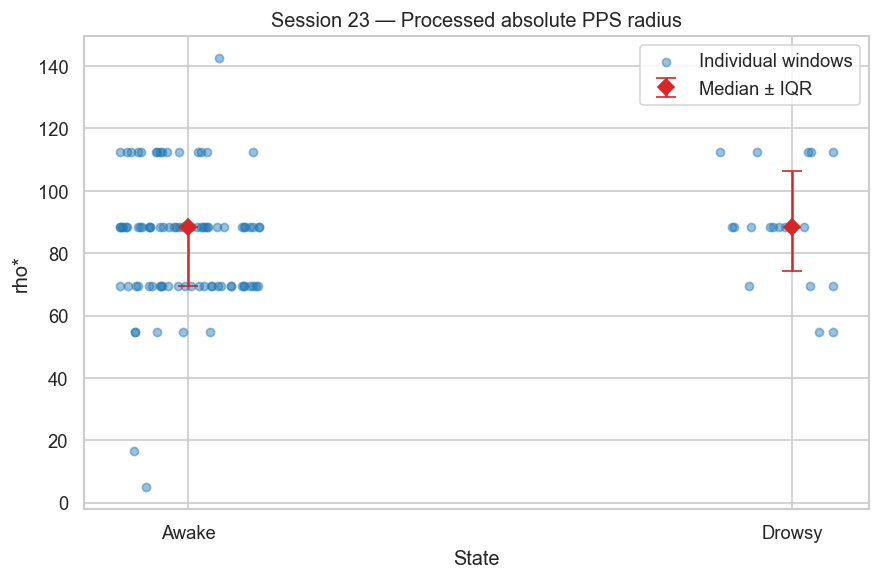

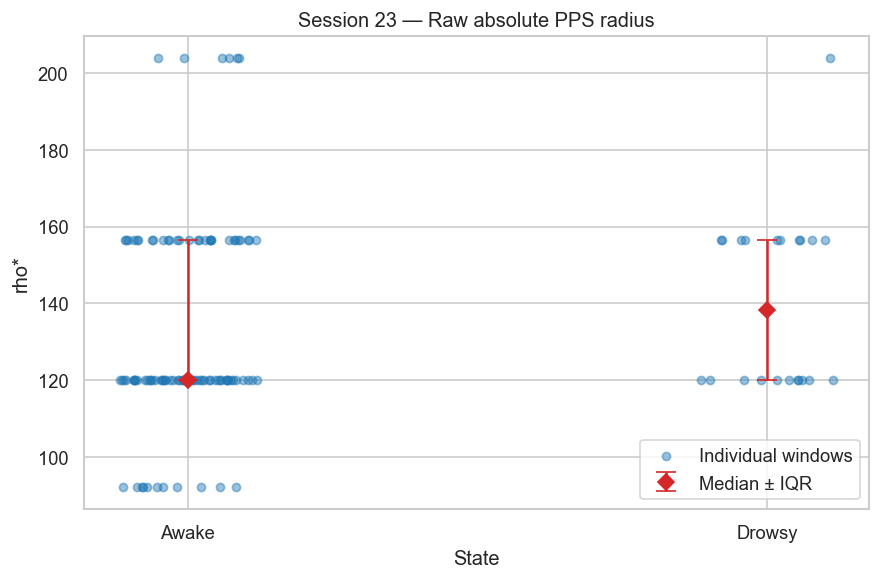

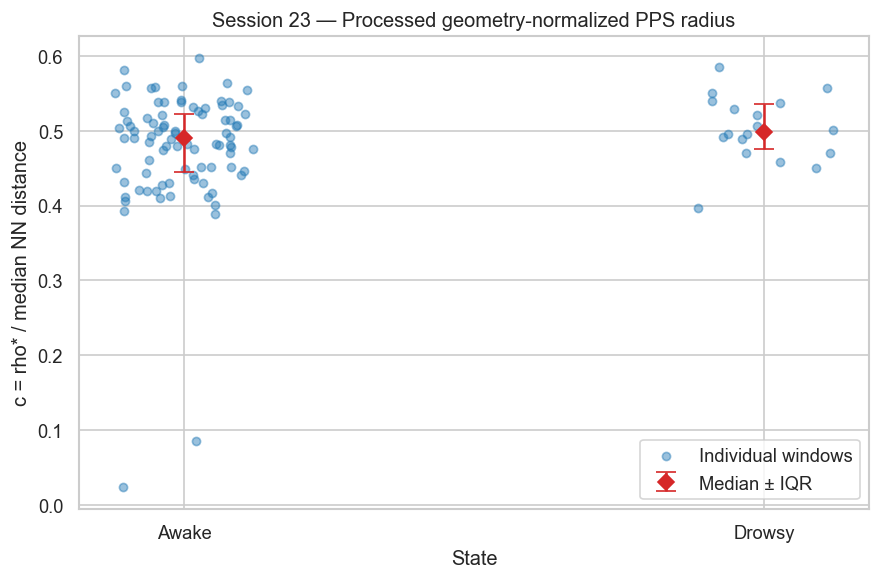

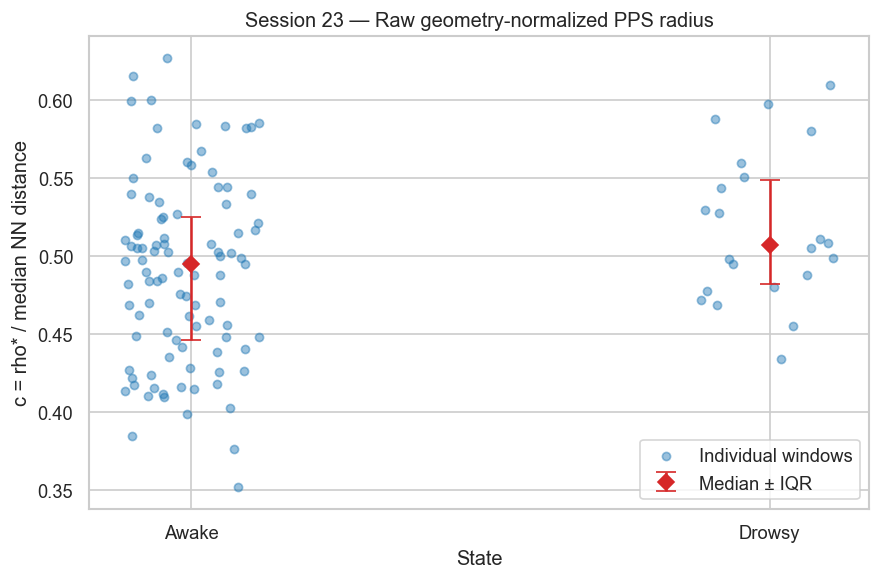

Eligible window counts:


,representation,state,window_size,N_windows
0,Processed,Awake,60,27
1,Processed,Awake,120,12
2,Processed,Awake,180,6
3,Processed,Drowsy,60,15
4,Processed,Drowsy,120,7
5,Processed,Drowsy,180,4
6,Raw,Awake,60,27
7,Raw,Awake,120,12
8,Raw,Awake,180,6
9,Raw,Drowsy,60,15


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    6.4s
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:    6.6s
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed:   19.1s
[Parallel(n_jobs=6)]: Done  20 tasks      | elapsed:   25.5s
[Parallel(n_jobs=6)]: Done  29 tasks      | elapsed:   48.2s
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:  1.3min
[Parallel(n_jobs=6)]: Done  49 tasks      | elapsed:  2.2min
[Parallel(n_jobs=6)]: Done  60 tasks      | elapsed:  2.3min
[Parallel(n_jobs=6)]: Done  73 tasks      | elapsed:  3.2min
[Parallel(n_jobs=6)]: Done  86 tasks      | elapsed:  3.6min
[Parallel(n_jobs=6)]: Done 101 tasks      | elapsed:  4.1min
[Parallel(n_jobs=6)]: Done 116 tasks      | elapsed:  5.4min
[Parallel(n_jobs=6)]: Done 142 out of 142 | elapsed:  7.1min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elap

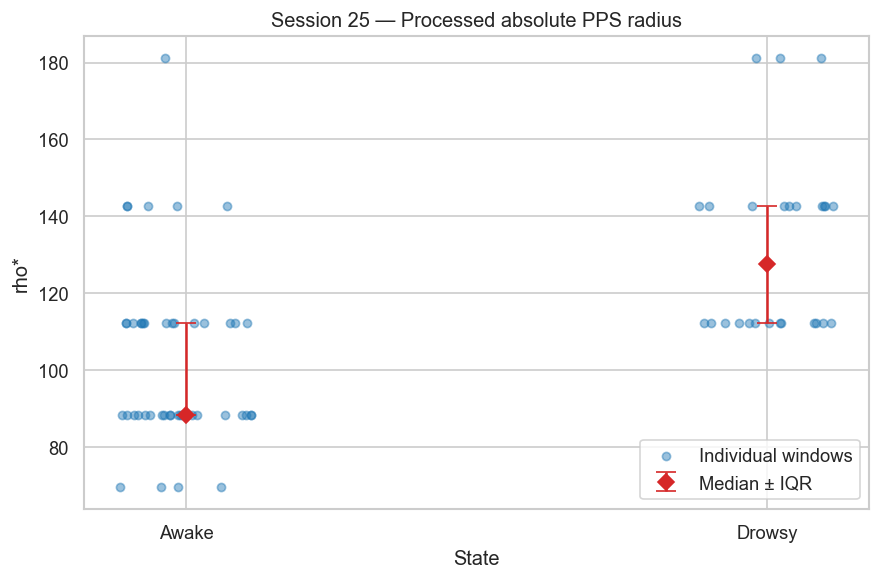

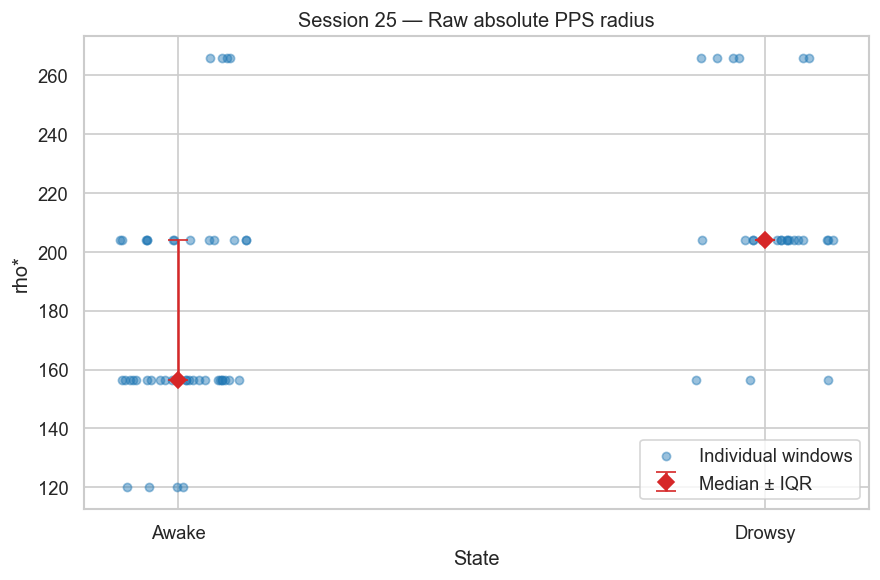

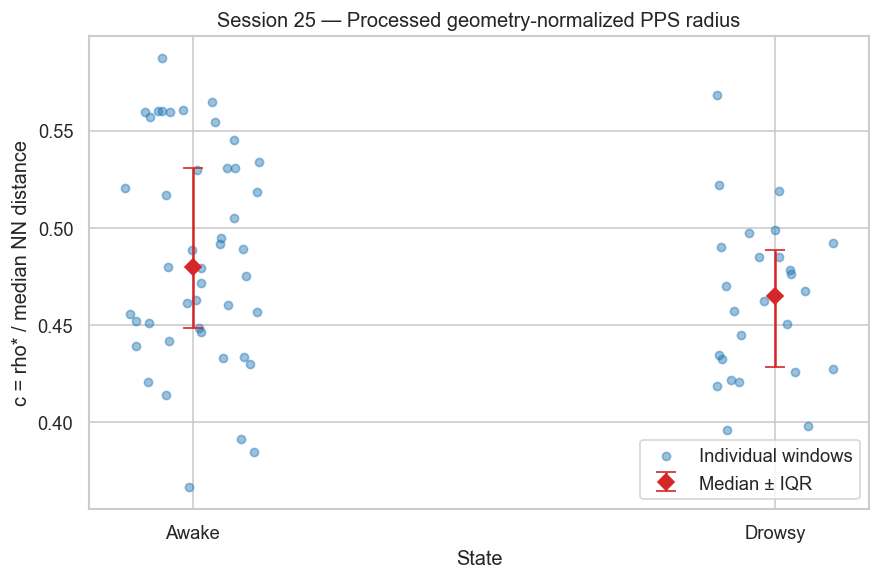

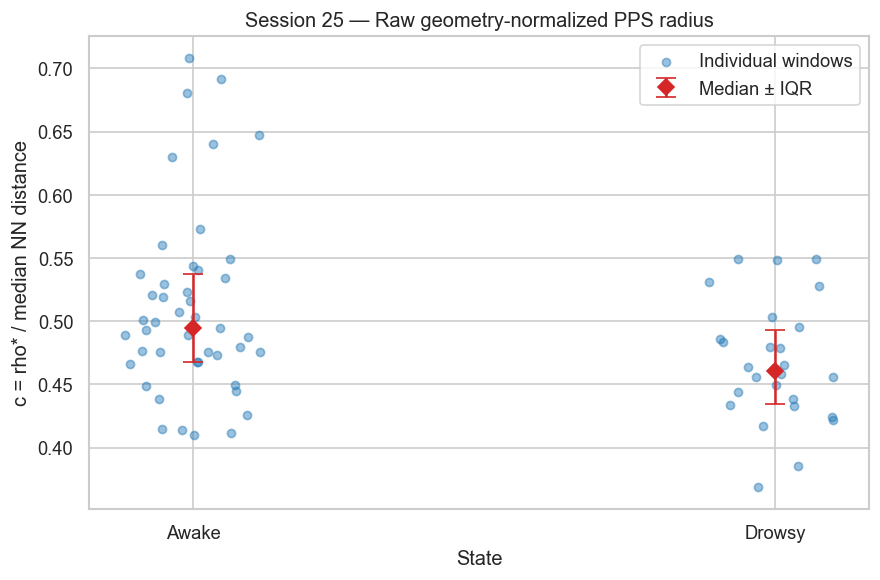

In [13]:
# TASK 11 - Reload the completed Session 10 run
for SESSION_ID in SESSIONS: 
    session_output = run_session(SESSION_ID, overwrite=False)
